In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import joblib

# --- 1. Chargement ---
df = pd.read_csv("C:/Users/maram/Downloads/annonces_brutes_202507021126/annonces_brutes_202507021126.csv", sep=';', low_memory=False)

# --- 2. Nettoyage avancé ---

# Suppression colonnes inutiles
to_drop = ['id', 'titre', 'url_annonce', 'vendeur', 'Numero_telephone', 'date_scraping', 'date_annonce', 'traitee', 'utile']
df.drop(columns=[c for c in to_drop if c in df.columns], inplace=True)

# Filtrer seulement les voitures (basé sur source ou description contenant 'voiture' ou similaire)
df = df[df['description'].str.contains('voiture|car|auto|vehicule', case=False, na=False) | df['source'].str.contains('voitures', case=False, na=False)]

def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if 'négociable' in x or x == '':
        return np.nan
    digits = re.findall(r'\d+', x)
    if not digits:
        return np.nan
    val = int(''.join(digits))
    if val < 5000:
        val *= 1000  # Assume '33' = 33000 TND
    return val

df['prix'] = df['prix'].apply(clean_price)

def clean_kilometrage(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    digits = re.findall(r'\d+', x)
    if not digits:
        return np.nan
    val = int(''.join(digits))
    if val < 1000:
        val *= 1000
    return val

df['kilometrage'] = df['kilometrage'].apply(clean_kilometrage)

def clean_puissance(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    match = re.findall(r'\d+\.?\d*', x)
    if not match:
        return np.nan
    return float(match[0])

df['puissance_fiscale'] = df['puissance_fiscale'].apply(clean_puissance)

def clean_year(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    match = re.search(r'(19|20)\d{2}', x)
    if match:
        return int(match.group(0))
    return np.nan

df['mise_en_circulation'] = df['mise_en_circulation'].apply(clean_year)

# Suppression des lignes sans prix
df.dropna(subset=['prix'], inplace=True)

# Calcul de l'âge
current_year = 2025
df['age'] = current_year - df['mise_en_circulation']
df['age'] = df['age'].clip(lower=1)  # Éviter 0

# Nouvelle feature: km_per_year
df['km_per_year'] = df['kilometrage'] / df['age']

# Extraction engine_size depuis description
def extract_engine_size(desc):
    if pd.isna(desc):
        return np.nan
    desc = str(desc).lower()
    match = re.search(r'(\d\.\d)\s*(l|tsi|cdi|tdi|essence|diesel)', desc)
    if match:
        return float(match.group(1))
    return np.nan

df['engine_size'] = df['description'].apply(extract_engine_size)

# Remplacement missing numériques par médiane
num_cols = ['kilometrage', 'puissance_fiscale', 'age', 'km_per_year', 'engine_size']
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Catégorielles
cat_cols = ['etat', 'carburant', 'boite_de_vitesse', 'marque', 'modele', 'couleur', 'ville', 'source']
for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip().fillna('inconnu').replace({'': 'inconnu'})
    df[col] = df[col].astype('category')  # Conversion en 'category' pour LightGBM

# Extraction features depuis description (étendu)
def extract_features_from_desc(desc):
    if pd.isna(desc):
        return {}
    desc = str(desc).lower()
    features = {
        'premiere_main': 1 if 'première main' in desc else 0,
        'toit_ouvrant': 1 if 'toit ouvrant' in desc or 'panoramique' in desc else 0,
        'camera_recul': 1 if 'caméra' in desc or 'recul' in desc else 0,
        'gps': 1 if 'gps' in desc or 'navigation' in desc else 0,
        'bluetooth': 1 if 'bluetooth' in desc else 0,
        'jantes_alu': 1 if 'jantes alu' in desc else 0,
        'climatronic': 1 if 'climatronic' in desc or 'clim' in desc else 0,
        'sieges_cuir': 1 if 'cuir' in desc and 'siège' in desc else 0,
        'radar': 1 if 'radar' in desc else 0,
        'full_options': 1 if 'full options' in desc or 'toute option' in desc else 0,
        'airbags': 1 if 'airbag' in desc else 0,
        'regulateur_vitesse': 1 if 'régulateur' in desc or 'cruise' in desc else 0,
    }
    return features

extra_feats = df['description'].apply(extract_features_from_desc)
extra_df = pd.DataFrame(list(extra_feats))
df = pd.concat([df, extra_df], axis=1)

# Drop description
df.drop(columns=['description'], inplace=True)

# Filtrer outliers
df = df[(df['prix'] >= 10000) & (df['prix'] <= 300000)]  # Prix raisonnables pour voitures d'occasion en Tunisie
df = df[(df['kilometrage'] >= 1000) & (df['kilometrage'] <= 500000)]
df = df[(df['mise_en_circulation'] >= 1990) & (df['mise_en_circulation'] <= 2025)]

# Supprimer doublons
df.drop_duplicates(inplace=True)

# --- 3. Préparation ---

X = df.drop('prix', axis=1)
y = np.log1p(df['prix'])  # Log transform pour skew

# --- 4. Entraînement avec Cross-Validation ---

params = {
    'objective': 'regression',
    'metric': ['mae', 'rmse'],
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,  # Plus bas pour précision
    'num_leaves': 128,      # Plus pour complexité
    'max_depth': 10,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,  # Anti-overfit
    'verbose': -1,
    'seed': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_list, rmse_list, r2_list = [], [], []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
    valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_cols, reference=train_data)
    
    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        num_boost_round=3000,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
    )
    
    y_pred_log = model.predict(X_test, num_iteration=model.best_iteration)
    y_pred = np.expm1(y_pred_log)  # Retour à échelle originale
    y_test_orig = np.expm1(y_test)
    
    mae_list.append(mean_absolute_error(y_test_orig, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test_orig, y_pred)))
    r2_list.append(r2_score(y_test_orig, y_pred))

print(f"MAE moyenne: {np.mean(mae_list):.2f}")
print(f"RMSE moyenne: {np.mean(rmse_list):.2f}")
print(f"R² moyenne: {np.mean(r2_list):.4f}")

# Entraîner sur tout pour sauvegarde
full_data = lgb.Dataset(X, label=y, categorical_feature=cat_cols)
model = lgb.train(params, full_data, num_boost_round=1000)
joblib.dump(model, 'modele_lightgbm_voiture_extraordinaire.pkl')
print("Modèle sauvegardé dans 'modele_lightgbm_voiture_extraordinaire.pkl'")

C:\Users\maram\AppData\Local\Temp\ipykernel_12416\3522119118.py:100: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\maram\AppData\Local\Temp\ipykernel_12416\3522119118.py:100: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Training until validation scores don't improve for 100 rounds
[100]	training's l1: 0.311955	training's rmse: 0.425072	valid_1's l1: 0.318046	valid_1's rmse: 0.436619
[200]	training's l1: 0.218938	training's rmse: 0.337134	valid_1's l1: 0.235365	valid_1's rmse: 0.369332
[300]	training's l1: 0.182713	training's rmse: 0.301617	valid_1's l1: 0.208188	valid_1's rmse: 0.351895
[400]	training's l1: 0.166384	training's rmse: 0.282138	valid_1's l1: 0.198993	valid_1's rmse: 0.346532
[500]	training's l1: 0.157324	training's rmse: 0.269086	valid_1's l1: 0.195246	valid_1's rmse: 0.344252
[600]	training's l1: 0.150674	training's rmse: 0.258442	valid_1's l1: 0.193624	valid_1's rmse: 0.342783
[700]	training's l1: 0.14439	training's rmse: 0.248103	valid_1's l1: 0.192186	valid_1's rmse: 0.341701
[800]	training's l1: 0.138887	training's rmse: 0.238656	valid_1's l1: 0.191246	valid_1's rmse: 0.340937
[900]	training's l1: 0.133809	training's rmse: 0.229592	valid_1's l1: 0.190776	valid_1's rmse: 0.340298
[10

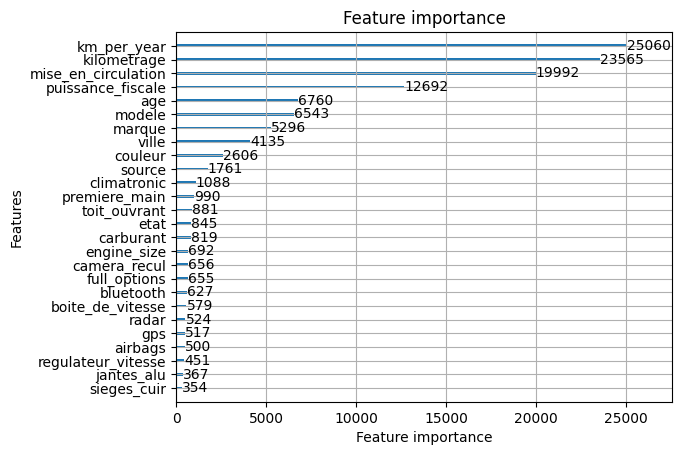

In [3]:
import lightgbm as lgb
import matplotlib.pyplot as plt
model = joblib.load('modele_lightgbm_voiture_extraordinaire.pkl')
lgb.plot_importance(model)
plt.show()

In [4]:
print("Colonnes utilisées pour entraîner le modèle :", list(X.columns))


Colonnes utilisées pour entraîner le modèle : ['source', 'etat', 'couleur', 'mise_en_circulation', 'carburant', 'boite_de_vitesse', 'kilometrage', 'puissance_fiscale', 'marque', 'modele', 'ville', 'age', 'km_per_year', 'engine_size', 'premiere_main', 'toit_ouvrant', 'camera_recul', 'gps', 'bluetooth', 'jantes_alu', 'climatronic', 'sieges_cuir', 'radar', 'full_options', 'airbags', 'regulateur_vitesse']


In [14]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import joblib

# --- Fonctions de nettoyage et préparation ---

def load_data(filepath):
    print("Chargement des données...")
    df = pd.read_csv(filepath, sep=';', low_memory=False)
    return df

def clean_data(df):
    print("Nettoyage des données...")

    to_drop = ['id', 'titre', 'url_annonce', 'vendeur', 'Numero_telephone', 'date_scraping', 'date_annonce', 'traitee', 'utile']
    df.drop(columns=[c for c in to_drop if c in df.columns], inplace=True)

    df = df[df['description'].str.contains('voiture|car|auto|vehicule', case=False, na=False) | 
            df['source'].str.contains('voitures', case=False, na=False)]

    def clean_price(x):
        if pd.isna(x):
            return np.nan
        x = str(x).strip().lower()
        if 'négociable' in x or x == '':
            return np.nan
        digits = re.findall(r'\d+', x)
        if not digits:
            return np.nan
        val = int(''.join(digits))
        if val < 5000:
            val *= 1000
        return val

    df['prix'] = df['prix'].apply(clean_price)

    def clean_kilometrage(x):
        if pd.isna(x):
            return np.nan
        x = str(x).strip().lower()
        digits = re.findall(r'\d+', x)
        if not digits:
            return np.nan
        val = int(''.join(digits))
        if val < 1000:
            val *= 1000
        return val

    df['kilometrage'] = df['kilometrage'].apply(clean_kilometrage)

    def clean_puissance(x):
        if pd.isna(x):
            return np.nan
        x = str(x).lower()
        match = re.findall(r'\d+\.?\d*', x)
        if not match:
            return np.nan
        return float(match[0])

    df['puissance_fiscale'] = df['puissance_fiscale'].apply(clean_puissance)

    def clean_year(x):
        if pd.isna(x):
            return np.nan
        x = str(x).strip()
        match = re.search(r'(19|20)\d{2}', x)
        if match:
            return int(match.group(0))
        return np.nan

    df['mise_en_circulation'] = df['mise_en_circulation'].apply(clean_year)

    df.dropna(subset=['prix'], inplace=True)

    current_year = 2025
    df['age'] = current_year - df['mise_en_circulation']
    df['age'] = df['age'].clip(lower=1)

    df['km_per_year'] = df['kilometrage'] / df['age']

    def extract_engine_size(desc):
        if pd.isna(desc):
            return np.nan
        desc = str(desc).lower()
        match = re.search(r'(\d\.\d)\s*(l|tsi|cdi|tdi|essence|diesel)', desc)
        if match:
            return float(match.group(1))
        return np.nan

    df['engine_size'] = df['description'].apply(extract_engine_size)

    num_cols = ['kilometrage', 'puissance_fiscale', 'age', 'km_per_year', 'engine_size']
    for col in num_cols:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

    cat_cols = ['etat', 'carburant', 'boite_de_vitesse', 'marque', 'modele', 'couleur', 'ville', 'source']
    for col in cat_cols:
        df[col] = df[col].astype(str).str.lower().str.strip().fillna('inconnu').replace({'': 'inconnu'})
        df[col] = df[col].astype('category')

    def extract_features_from_desc(desc):
        if pd.isna(desc):
            return {}
        desc = str(desc).lower()
        features = {
            'premiere_main': 1 if 'première main' in desc else 0,
            'toit_ouvrant': 1 if 'toit ouvrant' in desc or 'panoramique' in desc else 0,
            'camera_recul': 1 if 'caméra' in desc or 'recul' in desc else 0,
            'gps': 1 if 'gps' in desc or 'navigation' in desc else 0,
            'bluetooth': 1 if 'bluetooth' in desc else 0,
            'jantes_alu': 1 if 'jantes alu' in desc else 0,
            'climatronic': 1 if 'climatronic' in desc or 'clim' in desc else 0,
            'sieges_cuir': 1 if 'cuir' in desc and 'siège' in desc else 0,
            'radar': 1 if 'radar' in desc else 0,
            'full_options': 1 if 'full options' in desc or 'toute option' in desc else 0,
            'airbags': 1 if 'airbag' in desc else 0,
            'regulateur_vitesse': 1 if 'régulateur' in desc or 'cruise' in desc else 0,
        }
        return features

    extra_feats = df['description'].apply(extract_features_from_desc)
    extra_df = pd.DataFrame(list(extra_feats))
    df = pd.concat([df, extra_df], axis=1)

    df.drop(columns=['description'], inplace=True)

    df = df[(df['prix'] >= 10000) & (df['prix'] <= 300000)]
    df = df[(df['kilometrage'] >= 1000) & (df['kilometrage'] <= 500000)]
    df = df[(df['mise_en_circulation'] >= 1990) & (df['mise_en_circulation'] <= 2025)]

    df.drop_duplicates(inplace=True)

    return df, cat_cols

def train_and_evaluate(df, cat_cols):
    print("Préparation des données pour le modèle...")
    X = df.drop('prix', axis=1)
    y = np.log1p(df['prix'])

    params = {
        'objective': 'regression',
        'metric': ['mae', 'rmse'],
        'boosting_type': 'gbdt',
        'learning_rate': 0.01,
        'num_leaves': 128,
        'max_depth': 10,
        'feature_fraction': 0.7,
        'bagging_fraction': 0.7,
        'bagging_freq': 5,
        'min_data_in_leaf': 20,
        'verbose': -1,
        'seed': 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_list, rmse_list, r2_list = [], [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
        valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_cols, reference=train_data)

        model = lgb.train(
            params,
            train_data,
            valid_sets=[train_data, valid_data],
            num_boost_round=3000,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
        )

        y_pred_log = model.predict(X_test, num_iteration=model.best_iteration)
        y_pred = np.expm1(y_pred_log)
        y_test_orig = np.expm1(y_test)

        mae_list.append(mean_absolute_error(y_test_orig, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_test_orig, y_pred)))
        r2_list.append(r2_score(y_test_orig, y_pred))

    print(f"MAE moyenne: {np.mean(mae_list):.2f}")
    print(f"RMSE moyenne: {np.mean(rmse_list):.2f}")
    print(f"R² moyenne: {np.mean(r2_list):.4f}")

    return model, X, y

def save_model(model, X, y, cat_cols, filename='modele_lightgbm_voiture_extraordinaire.pkl'):
    print("Entraînement final sur toutes les données et sauvegarde du modèle...")
    full_data = lgb.Dataset(X, label=y, categorical_feature=cat_cols)
    model = lgb.train(model.params, full_data, num_boost_round=1000)
    joblib.dump(model, filename)
    print(f"Modèle sauvegardé dans '{filename}'")

# --- Pipeline principal ---
def run_pipeline(filepath):
    df = load_data(filepath)
    df, cat_cols = clean_data(df)
    model, X, y = train_and_evaluate(df, cat_cols)
    save_model(model, X, y, cat_cols)

# --- Exécution ---
if __name__ == '__main__':
    run_pipeline("C:/Users/maram/Downloads/annonces_brutes_202507021126/annonces_brutes_202507021126.csv")


Chargement des données...
Nettoyage des données...
Préparation des données pour le modèle...
Training until validation scores don't improve for 100 rounds
[100]	training's l1: 0.311955	training's rmse: 0.425072	valid_1's l1: 0.318046	valid_1's rmse: 0.436619
[200]	training's l1: 0.218938	training's rmse: 0.337134	valid_1's l1: 0.235365	valid_1's rmse: 0.369332
[300]	training's l1: 0.182713	training's rmse: 0.301617	valid_1's l1: 0.208188	valid_1's rmse: 0.351895
[400]	training's l1: 0.166384	training's rmse: 0.282138	valid_1's l1: 0.198993	valid_1's rmse: 0.346532
[500]	training's l1: 0.157324	training's rmse: 0.269086	valid_1's l1: 0.195246	valid_1's rmse: 0.344252
[600]	training's l1: 0.150674	training's rmse: 0.258442	valid_1's l1: 0.193624	valid_1's rmse: 0.342783
[700]	training's l1: 0.14439	training's rmse: 0.248103	valid_1's l1: 0.192186	valid_1's rmse: 0.341701
[800]	training's l1: 0.138887	training's rmse: 0.238656	valid_1's l1: 0.191246	valid_1's rmse: 0.340937
[900]	training

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
train_pipeline_pfe.py

Pipeline professionnel pour prédiction du prix des voitures (PFE)
- Nettoyage avancé
- Feature engineering (text TF-IDF + numeric features + interactions)
- Stratified K-Fold (sur bins de prix)
- Optuna pour LGBM (petit nombre d'essais par défaut)
- Stacking: LGBM + CatBoost + XGBoost -> méta Ridge
- SHAP pour interprétabilité
- Sauvegarde des artefacts
"""

import os
import re
import joblib
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor

import optuna

# modèles
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb

# interprétabilité
import shap

# ---------------------------
# CONFIG
# ---------------------------
INPUT_CSV = r"C:/Users/maram/Downloads/annonces_brutes_202507021126/annonces_brutes_202507021126.csv"
OUTPUT_DIR = "outputs_pfe"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
CURRENT_YEAR = 2025

N_SPLITS = 5           # CV splits
N_TRIALS_OPTUNA = 25   # augmenter si tu as le temps (50-100)
MAX_TFIDF_FEATURES = 2000
RANDOM_SEED = RANDOM_STATE

# ---------------------------
# UTILITAIRES DE NETTOYAGE
# ---------------------------
def clean_price(x):
    """Nettoyage du champ prix - retourne float (TND) ou np.nan"""
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    # enlever mots non numériques
    s = re.sub(r'[^\d,\.]', '', s)
    s = s.replace(',', '')  # supposer pas de décimales significatives
    if s == '':
        return np.nan
    try:
        val = float(s)
    except:
        return np.nan
    # heuristique si valeur trop petite -> multiplier par 1000
    if val < 1000:
        val = val * 1000
    return float(val)

def clean_int_field(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    digits = re.findall(r'\d+', s)
    return int(''.join(digits)) if digits else np.nan

def extract_engine_size(desc):
    if pd.isna(desc):
        return np.nan
    s = str(desc).lower()
    # chercher 1.6l 2.0 l etc
    m = re.search(r'(\d\.\d)\s*l', s)
    if m:
        return float(m.group(1))
    # chercher patterns '1600 cc' -> 1.6
    m2 = re.search(r'(\d{3,4})\s*cc', s)
    if m2:
        val = int(m2.group(1))
        return round(val / 1000.0, 2)
    return np.nan

def extract_features_from_desc(desc):
    """Retourne dict de flags utiles"""
    if pd.isna(desc):
        desc = ''
    s = str(desc).lower()
    return {
        'premiere_main': int('première main' in s or '1ère main' in s or '1ere main' in s),
        'toit_ouvrant': int('toit ouvrant' in s or 'panoramique' in s),
        'camera_recul': int('camera' in s or 'caméra' in s or 'recul' in s),
        'gps': int('gps' in s or 'navigation' in s),
        'bluetooth': int('bluetooth' in s),
        'jantes_alu': int('jantes alu' in s or 'jantes alliage' in s),
        'sieges_cuir': int('siège cuir' in s or 'sièges cuir' in s or 'cuir' in s and 'siège' in s),
        'full_options': int('full options' in s or 'toute option' in s or 'toute les options' in s),
        'airbags': int('airbag' in s),
        'regulateur_vitesse': int('régulateur' in s or 'cruise control' in s or 'cruise' in s),
        'hybride': int('hybride' in s),
        'electrique': int('électrique' in s or 'electrique' in s),
    }

# ---------------------------
# TRANSFORMER CUSTOM (pour pipeline)
# ---------------------------
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Transforme DataFrame en DataFrame avec features numériques et catégorielles prêtes.
    Ne gère pas la vectorisation TF-IDF (fait séparément).
    """
    def __init__(self, current_year=CURRENT_YEAR):
        self.current_year = current_year
        self.num_cols = ['kilometrage', 'puissance_fiscale', 'mise_en_circulation',
                         'age', 'km_per_year', 'engine_size']
        self.desc_flags = ['premiere_main','toit_ouvrant','camera_recul','gps',
                           'bluetooth','jantes_alu','sieges_cuir','full_options',
                           'airbags','regulateur_vitesse','hybride','electrique']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        # colonnes d'origine attendues (adapter si ton CSV diffère)
        # Nettoyage simples
        df['prix_clean'] = df.get('prix', df.get('price', np.nan)).apply(clean_price)
        df['kilometrage'] = df.get('kilometrage', df.get('mileage', np.nan)).apply(clean_int_field)
        # Remplace cette ligne dans FeatureEngineer.transform
df['puissance_fiscale'] = df.get('puissance_fiscale', np.nan).apply(
    lambda x: (
        float(re.sub(r"[^\d.]", "", str(x))) if pd.notna(x) and re.sub(r"[^\d.]", "", str(x)) != "" else np.nan
    )
)

        df['mise_en_circulation'] = df.get('mise_en_circulation', df.get('year', np.nan)).apply(clean_int_field)

        # age
        df['age'] = self.current_year - df['mise_en_circulation']
        df.loc[df['age'] <= 0, 'age'] = 1  # évite 0 ou négatif

        # km_per_year
        df['km_per_year'] = df['kilometrage'] / (df['age'] + 1)

        # engine_size
        df['engine_size'] = df.get('engine_size', np.nan)
        if 'description' in df.columns:
            df['engine_size'] = df['engine_size'].fillna(df['description'].apply(extract_engine_size))

        # flags from description
        if 'description' in df.columns:
            flags_df = df['description'].apply(extract_features_from_desc).apply(pd.Series)
            for c in self.desc_flags:
                if c in flags_df.columns:
                    df[c] = flags_df[c]
                else:
                    df[c] = 0
        else:
            for c in self.desc_flags:
                df[c] = 0

        # interactions
        df['price_per_km'] = df['prix_clean'] / (df['kilometrage'] + 1)
        df['power_per_liter'] = df['puissance_fiscale'] / (df['engine_size'].replace(0, np.nan) + 1e-6)
        df['age_mul_km_per_year'] = df['age'] * df['km_per_year']

        # garder colonnes utiles
        keep_cols = [
            'prix_clean', 'kilometrage', 'puissance_fiscale', 'mise_en_circulation',
            'age', 'km_per_year', 'engine_size', 'price_per_km', 'power_per_liter', 'age_mul_km_per_year'
        ] + self.desc_flags

        # colonnes catégorielles communes (peux adapter selon dataset)
        cat_expected = ['etat','carburant','boite_de_vitesse','marque','modele','couleur','ville','source']
        for c in cat_expected:
            if c in df.columns:
                df[c] = df[c].astype(str).str.lower().str.strip().fillna('inconnu')
            else:
                df[c] = 'inconnu'

            keep_cols.append(c)

        result = df[keep_cols].copy()
        return result

# ---------------------------
# MAIN: Chargement + nettoyage global + pipeline
# ---------------------------
def load_and_clean(path):
    print(f"[{datetime.now()}] Chargement des données depuis: {path}")
    df = pd.read_csv(path, sep=';', low_memory=False)
    print(f"[{datetime.now()}] Shape initiale: {df.shape}")

    # supprimer colonnes inutiles si présentes
    drop_if_exist = ['id', 'titre', 'url_annonce', 'vendeur', 'Numero_telephone', 'date_scraping', 'date_annonce', 'traitee', 'utile']
    df.drop(columns=[c for c in drop_if_exist if c in df.columns], inplace=True, errors='ignore')

    # garder seulement annonces de voitures (heuristique)
    if 'description' in df.columns and 'source' in df.columns:
        mask = df['description'].str.contains('voiture|auto|car|véhicule|vehicule', case=False, na=False) | df['source'].str.contains('voitures', case=False, na=False)
        df = df[mask]
    print(f"[{datetime.now()}] Après filter voitures: {df.shape}")

    # suppr lignes sans prix
    if 'prix' in df.columns:
        df['prix'] = df['prix'].apply(clean_price)
        df = df[df['prix'].notna()]
    elif 'price' in df.columns:
        df['price'] = df['price'].apply(clean_price)
        df = df[df['price'].notna()]

    # suppression outliers prix via IQR
    target_col = 'prix' if 'prix' in df.columns else 'price'
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    df = df[(df[target_col] >= max(0, low)) & (df[target_col] <= high)]
    print(f"[{datetime.now()}] Après IQR filter: {df.shape}")

    df.drop_duplicates(inplace=True)
    print(f"[{datetime.now()}] Après drop_duplicates: {df.shape}")

    return df

# ---------------------------
# FUNCTIONS DE VALIDATION (bins)
# ---------------------------
def make_price_bins(y, n_bins=10):
    """Crée bins pour stratification sur la cible (prix)"""
    y = np.array(y)
    bins = np.quantile(y, np.linspace(0, 1, n_bins + 1))
    # utiliser np.digitize mais s'assurer que dernière bin incluse
    bin_idx = np.digitize(y, bins[1:-1], right=True)
    return bin_idx

# ---------------------------
# OPTUNA objective pour LightGBM (rapide)
# ---------------------------
def optuna_lgb_objective(trial, X, y, categorical_features):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 4, 16),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0),
        'seed': RANDOM_SEED
    }

    kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    rmse_scores = []
    bins = make_price_bins(np.expm1(y))  # y is log1p

    for tr_idx, val_idx in kf.split(X, bins):
        dtrain = lgb.Dataset(X.iloc[tr_idx], label=y.iloc[tr_idx], categorical_feature=categorical_features)
        dval = lgb.Dataset(X.iloc[val_idx], label=y.iloc[val_idx], reference=dtrain, categorical_feature=categorical_features)
        model = lgb.train(params, dtrain, num_boost_round=2000, valid_sets=[dval], early_stopping_rounds=80, verbose_eval=False)
        preds_log = model.predict(X.iloc[val_idx], num_iteration=model.best_iteration)
        preds = np.expm1(preds_log)
        y_true = np.expm1(y.iloc[val_idx])
        rmse_scores.append(np.sqrt(mean_squared_error(y_true, preds)))
    return float(np.mean(rmse_scores))

# ---------------------------
# ENTRAÎNEMENT ET STACKING
# ---------------------------
def train_pipeline(df):
    # Feature engineering
    fe = FeatureEngineer(current_year=CURRENT_YEAR)
    X_fe = fe.fit_transform(df)

    # target
    target_col = 'prix_clean' if 'prix_clean' in X_fe.columns else 'prix' if 'prix' in df.columns else 'price'
    y = np.log1p(X_fe[target_col])
    X_fe = X_fe.drop(columns=[target_col])

    # texte: TF-IDF sur description original
    text_col = 'description' if 'description' in df.columns else None
    if text_col:
        tfidf = TfidfVectorizer(max_features=MAX_TFIDF_FEATURES, ngram_range=(1,2), stop_words='french')
        tfidf_mat = tfidf.fit_transform(df[text_col].fillna('').values)
        # convertir tfidf sparse -> DataFrame avec noms prefixés
        tfidf_df = pd.DataFrame(tfidf_mat.toarray(), columns=[f"tfidf_{i}" for i in range(tfidf_mat.shape[1])], index=X_fe.index)
        X_full = pd.concat([X_fe.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)
    else:
        tfidf = None
        X_full = X_fe.copy()

    # Colonnes numériques et catégorielles
    numeric_cols = X_fe.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_fe.columns if c not in numeric_cols]

    print(f"[{datetime.now()}] Numeric cols: {len(numeric_cols)}, Categorical cols: {len(categorical_cols)}")

    # Imputation/Scaling pour features numériques
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Pour les colonnes catégorielles, on utilisera LabelEncoding / ordinal via pandas factorize
    X_work = X_full.copy()
    # target encoding léger: fréquence (popularité) + factorize
    for c in categorical_cols:
        # fréquence
        freq = X_work[c].fillna('inconnu').astype(str).value_counts(normalize=True)
        X_work[f"{c}_freq"] = X_work[c].fillna('inconnu').astype(str).map(freq).fillna(0)
        # factorize (simple label)
        X_work[c] = pd.factorize(X_work[c].fillna('inconnu').astype(str))[0]

    # Mettre à jour listes
    numeric_cols = X_work.select_dtypes(include=[np.number]).columns.tolist()
    # Retirer potentiellement colonnes tfidf de la liste des catégorielles (si existent)
    # Maintenant tout est numérique (factorize), donc ok.

    # Sélection finale
    X_final = X_work.copy()

    # -----------------
    # OPTUNA pour LGBM (sur X_final)
    # -----------------
    print(f"[{datetime.now()}] Lancement Optuna pour LightGBM ({N_TRIALS_OPTUNA} trials)...")
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    func = lambda trial: optuna_lgb_objective(trial, X_final, y, categorical_features=[])
    study.optimize(func, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)
    best_lgb_params = study.best_params
    print(f"[{datetime.now()}] Best LGB params: {best_lgb_params}")

    # Construire modèles de base avec params convenables
    lgb_model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        random_state=RANDOM_SEED,
        n_estimators=1500,
        **best_lgb_params
    )

    cat_model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=6,
        eval_metric='RMSE',
        random_seed=RANDOM_SEED,
        verbose=0
    )

    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=6,
        random_state=RANDOM_SEED,
        verbosity=0
    )

    # Stacking: utiliser Ridge comme méta-modèle
    estimators = [
        ('lgb', lgb_model),
        ('cat', cat_model),
        ('xgb', xgb_model)
    ]

    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0, random_state=RANDOM_SEED),
        cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED),
        passthrough=False,
        n_jobs=-1
    )

    # Évaluation via CV (pour rapport)
    print(f"[{datetime.now()}] Évaluation CV du stacking...")
    kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    bins = make_price_bins(np.expm1(y))
    maes, rmses, r2s = [], [], []

    for tr_idx, val_idx in kf.split(X_final, bins):
        X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        stack.fit(X_tr, y_tr)
        preds_log = stack.predict(X_val)
        preds = np.expm1(preds_log)
        y_true = np.expm1(y_val)
        maes.append(mean_absolute_error(y_true, preds))
        rmses.append(np.sqrt(mean_squared_error(y_true, preds)))
        r2s.append(r2_score(y_true, preds))

    print(f"MAE CV moy.: {np.mean(maes):.2f}")
    print(f"RMSE CV moy.: {np.mean(rmses):.2f}")
    print(f"R2 CV moy.: {np.mean(r2s):.4f}")

    # Entraîner sur tout le jeu
    print(f"[{datetime.now()}] Entraînement final sur tout le dataset...")
    stack.fit(X_final, y)

    # Sauvegarde artefacts
    joblib.dump(stack, os.path.join(OUTPUT_DIR, "stack_model.joblib"))
    if tfidf is not None:
        joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf_vectorizer.joblib"))
    joblib.dump(fe, os.path.join(OUTPUT_DIR, "feature_engineer.joblib"))
    joblib.dump(study.best_params, os.path.join(OUTPUT_DIR, "best_lgb_params.json"))
    print(f"[{datetime.now()}] Modèles et artefacts sauvegardés dans: {OUTPUT_DIR}")

    # Feature importance via SHAP (sur LGB modèle empilé - on prend lgb final inside stack)
    try:
        print(f"[{datetime.now()}] Calcul SHAP (peut être long)...")
        # récupérer lgb interne si possible
        lgb_in_stack = None
        for name, est in stack.named_estimators_.items():
            if name.startswith('lgb'):
                lgb_in_stack = est
                break
        if lgb_in_stack is not None:
            # transformer X_final (déjà prêt) -> numpy
            explainer = shap.TreeExplainer(lgb_in_stack)
            # attention: shap peut consommer bcp de mémoire; échantillonner si dataset large
            sample = X_final.sample(n=min(2000, X_final.shape[0]), random_state=RANDOM_SEED)
            shap_values = explainer.shap_values(sample)
            # sauvegarder shap (petit échantillon)
            joblib.dump({'sample_index': sample.index.tolist(), 'shap_values': shap_values}, os.path.join(OUTPUT_DIR, "shap_lgb_sample.joblib"))
            print(f"[{datetime.now()}] SHAP calculé et sauvegardé (échantillon).")
        else:
            print("Impossible de trouver LGB dans le stacking pour SHAP.")
    except Exception as e:
        print("Erreur SHAP:", e)

    # Evaluation finale sur training (report)
    preds_log_full = stack.predict(X_final)
    preds_full = np.expm1(preds_log_full)
    y_true_full = np.expm1(y)
    print("=== Rapport final (sur tout le dataset) ===")
    print("RMSE:", np.sqrt(mean_squared_error(y_true_full, preds_full)))
    print("MAE:", mean_absolute_error(y_true_full, preds_full))
    print("R2:", r2_score(y_true_full, preds_full))

    return stack

# ---------------------------
# EXECUTION
# ---------------------------
if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    df_raw = load_and_clean(INPUT_CSV)
    model = train_pipeline(df_raw)
    print("Terminé.")


FileNotFoundError: [Errno 2] No such file or directory: 'voitures.csv'

In [6]:
!pip install pandas numpy scikit-learn lightgbm xgboost catboost optuna shap joblib


   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 1.2 MB/s eta 0:01:26
   ---------------------------------------- 0.8/102.4 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 1.0/102.4 MB 1.1 MB/s eta 0:01:33
    --------------------------------------- 1.3/102.4 MB 1.2 MB/s eta 0:01:23
    --------------------------------------- 1.6/102.4 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.8/102.4 MB 1.2 MB/s eta 0:01:25
    --------------------------------------- 2.1/102.4 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 2.4/102.4 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 2.4/102.4 MB 1.2 MB/s eta 0:01:26
   - -------------------------------------- 2.6/102.4 MB 1.2 MB/s eta 0:01:26
   - --

  You can safely remove it manually.
  You can safely remove it manually.
